##### This script contains the following:


#### 1. Importing libraries and datasets
#### 2. Loading and Pre-Processing the Weather Images
#### 3. Compiling and Running
#### 4. Results

### 1. Importing libraries and datasets

In [3]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation, Dropout
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # Updated import
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

### 2. Loading and Pre-Processing the Weather Images

In [6]:
#download the weather images and put them in a directory
path = '/Users/peterguan/ClimateWins ML/Data Sets/Multi-class Weather Dataset'
folders = os.listdir(path)
print(folders)

['Cloudy', 'Rain', '.DS_Store', 'Shine', 'Sunrise']


In [8]:
#this will load in the pictures and rescale them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


In [10]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

### 3. Compiling and Running

In [23]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 17, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/17
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 395ms/step - accuracy: 0.8569 - loss: 0.0516 - val_accuracy: 0.8438 - val_loss: 0.0610
Epoch 2/17
 1/28 ━━━━━━━━━━━━━━━━━━━━ 9s 343ms/step - accuracy: 0.9375 - loss: 0.0137

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9375 - loss: 0.0137 - val_accuracy: 0.8527 - val_loss: 0.0570
Epoch 3/17
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 388ms/step - accuracy: 0.9335 - loss: 0.0271 - val_accuracy: 0.8348 - val_loss: 0.0704
Epoch 4/17
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9688 - loss: 0.0170 - val_accuracy: 0.8304 - val_loss: 0.0714
Epoch 5/17
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 383ms/step - accuracy: 0.9241 - loss: 0.0306 - val_accuracy: 0.8795 - val_loss: 0.0493
Epoch 6/17
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9062 - loss: 0.0485 - val_accuracy: 0.8616 - val_loss: 0.0511
Epoch 7/17
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 393ms/step - accuracy: 0.9041 - loss: 0.0350 - val_accuracy: 0.8259 - val_loss: 0.0750
Epoch 8/17
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9062 - loss: 0.0375 - val_accuracy: 0.8259 - val_loss: 0.0621
Epoch 9/17
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 390ms/step - accuracy: 0.9264 - loss: 0.0331 - val_accuracy: 0.8571 - val_

In [25]:
results = pd.DataFrame(model.history.history)

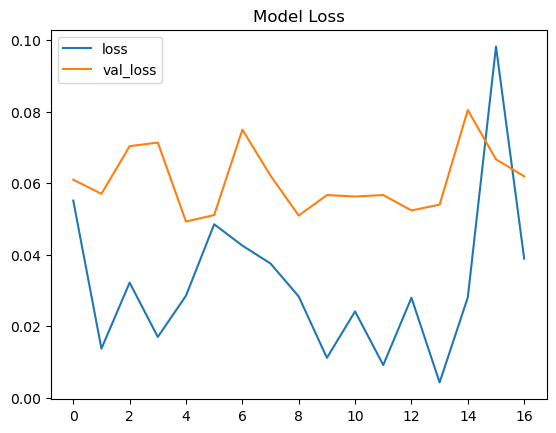

In [29]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

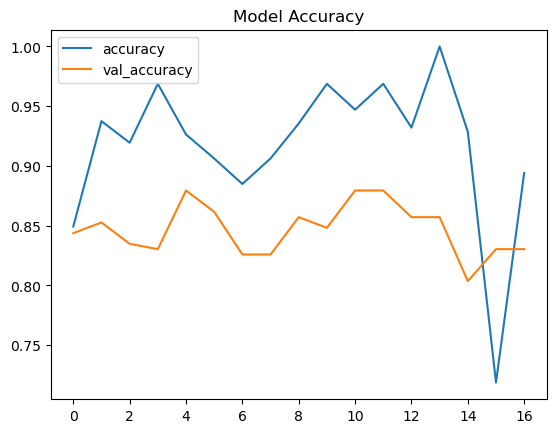

In [44]:
results[['accuracy','val_accuracy']].plot(title='Model Accuracy')
plt.savefig('./accuracy.png')

In [33]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.8941311836242676, Val_Accuracy: 0.8303571343421936
Loss: 0.03890381008386612, Val_Loss: 0.06192261353135109


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step


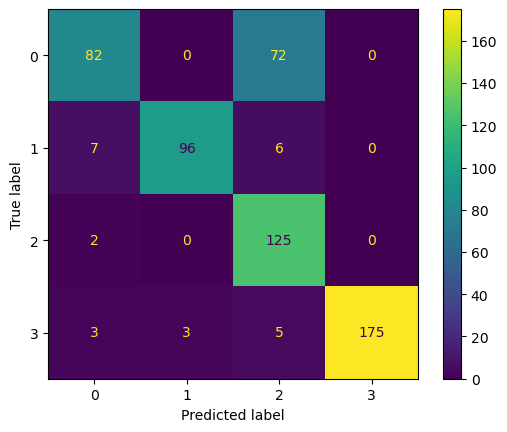

In [35]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 17 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [37]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


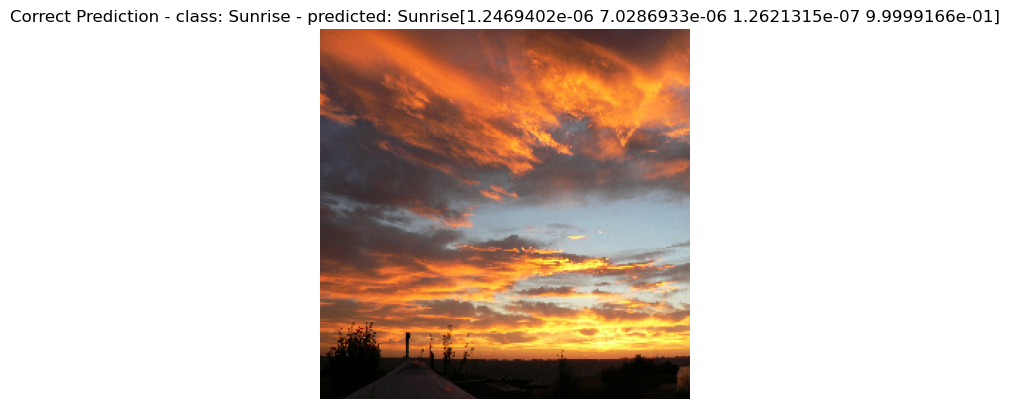

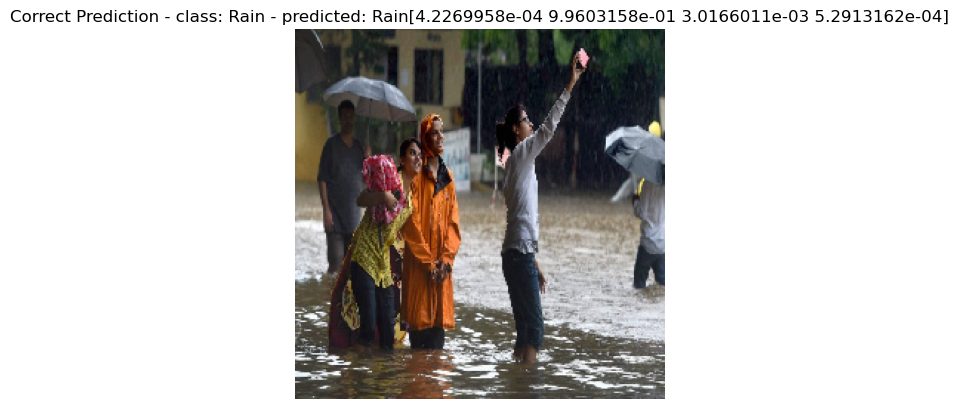

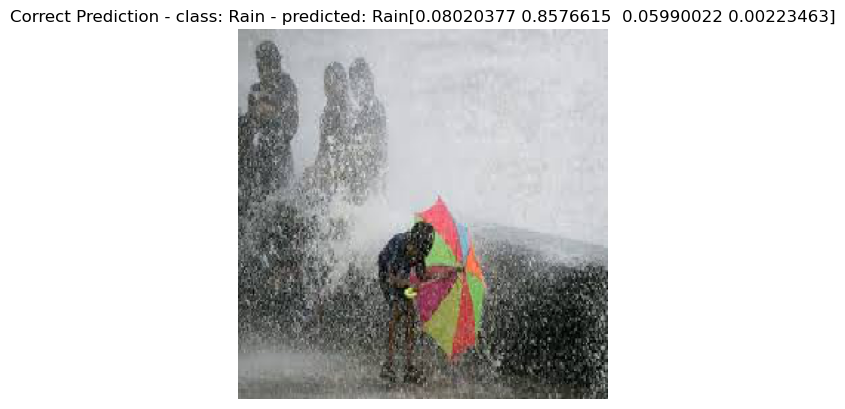

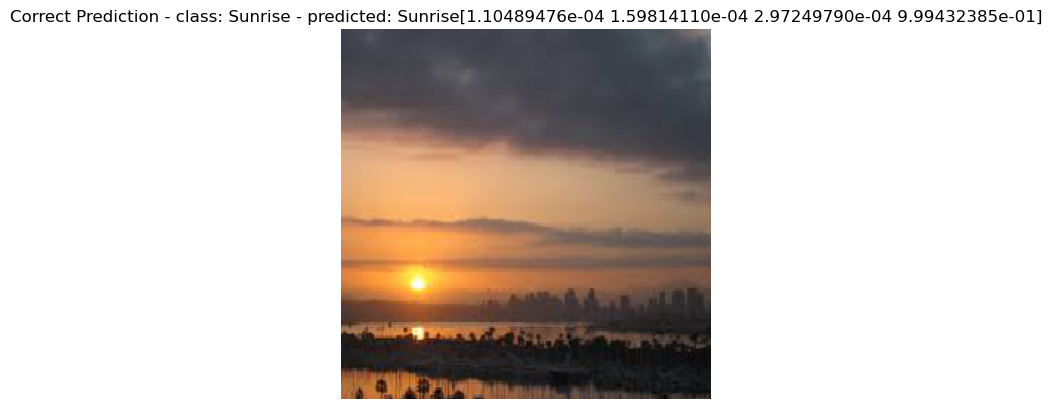

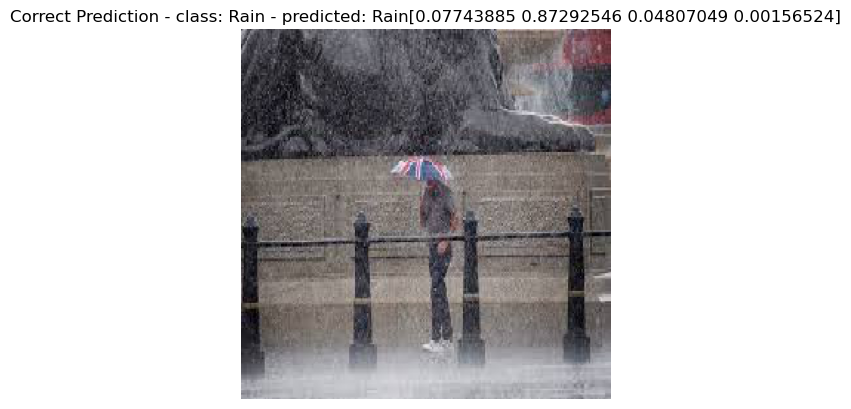

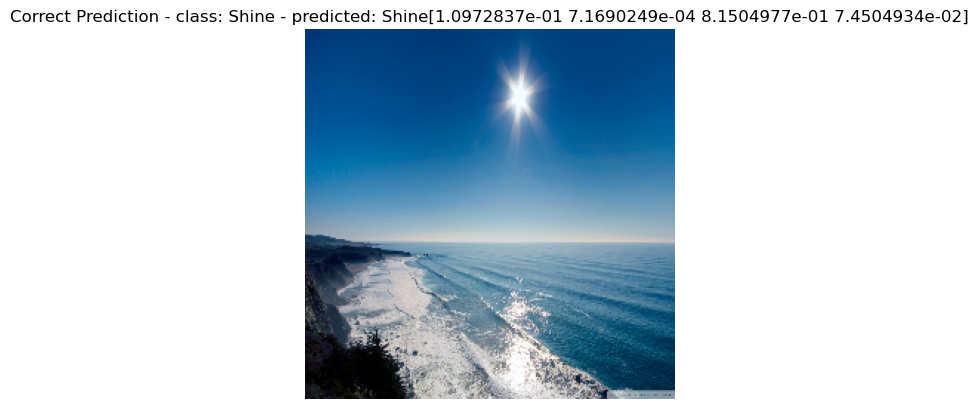

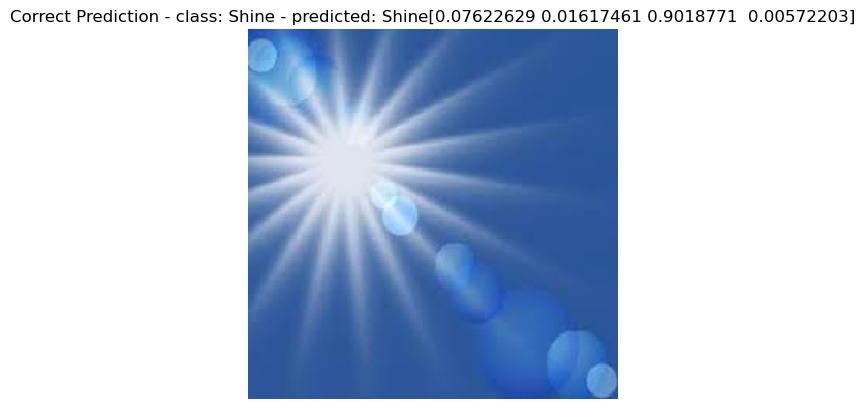

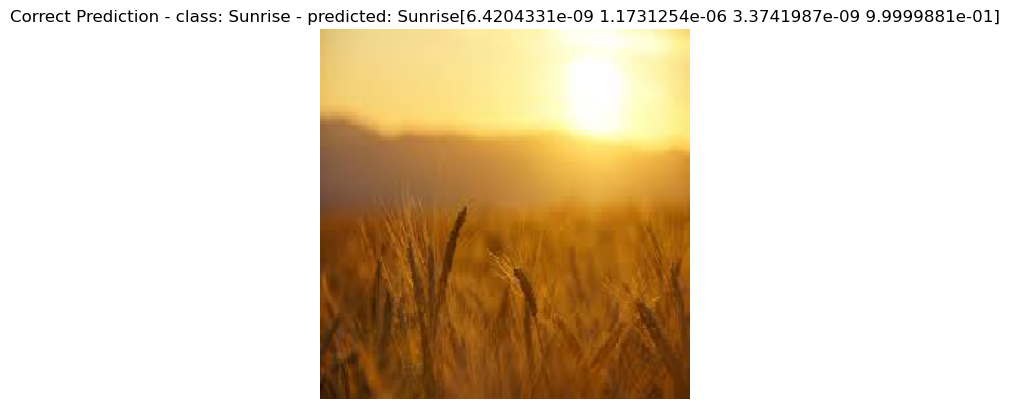

In [41]:
predict_one(model, 8) #<--you can show multiple pictures with this command. Just fill in the number you want to see.